In [3]:
import numpy as np
import matplotlib.pyplot as plt

Taxa de aceitação: 0.3336
Número de amostras aceitas: 100000


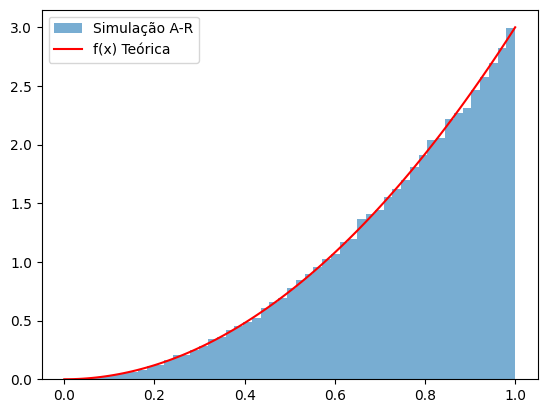

In [5]:
# a) Implemente aceitação-rejeição.
N = 100000
amostras_aceitas = []
tentativas = 0

for _ in range(N):
    while True:
        tentativas += 1
        Y = np.random.uniform(0, 1)  # Gerar de g(x)
        U = np.random.uniform(0, 1)  # Variável de decisão
        if U <= Y**2:                # Condição f(Y)/(c*g(Y))
            amostras_aceitas.append(Y)
            break
print(f'Taxa de aceitação: {len(amostras_aceitas)/tentativas:.4f}') 
print(f'Número de amostras aceitas: {len(amostras_aceitas)}')

# Gráfico para conferência
x = np.linspace(0, 1, 100)
plt.hist(amostras_aceitas, bins=50, density=True, alpha=0.6, label='Simulação A-R')
plt.plot(x, 3*x**2, 'r', label='f(x) Teórica')
plt.legend()
plt.show()

Taxa de Aceitação Analítica: 0.3333
Taxa de Aceitação Simulada: 0.3347


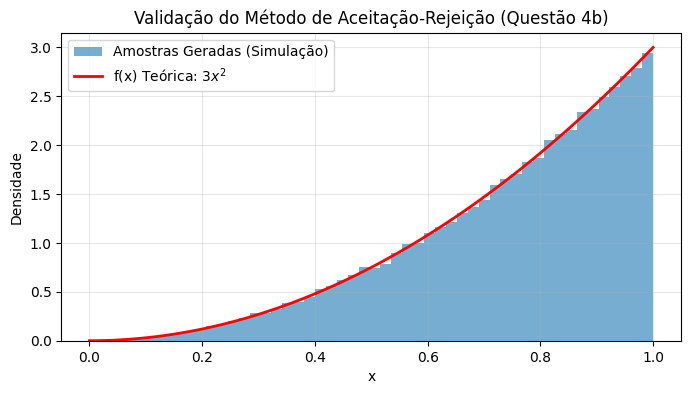

In [4]:
#b) Calcule taxa de aceitação.
N = 100000
amostras_aceitas = []
tentativas_totais = 0

# Aceitação-Rejeição
while len(amostras_aceitas) < N:
    tentativas_totais += 1
    Y = np.random.uniform(0, 1)  # Gerar de g(x)
    U = np.random.uniform(0, 1)  # Variável de decisão
    
    # Critério: U <= f(Y)/(c*g(Y)) -> U <= (3Y^2)/(3*1) -> U <= Y^2
    if U <= Y**2:
        amostras_aceitas.append(Y)

# Cálculo da Taxa de Aceitação Simulada
taxa_simulada = len(amostras_aceitas) / tentativas_totais

print(f"Taxa de Aceitação Analítica: {1/3:.4f}")
print(f"Taxa de Aceitação Simulada: {taxa_simulada:.4f}")

# CÓDIGO DO GRÁFICO
x = np.linspace(0, 1, 100)
plt.figure(figsize=(8, 4))
plt.hist(amostras_aceitas, bins=50, density=True, alpha=0.6, label='Amostras Geradas (Simulação)')
plt.plot(x, 3*x**2, 'r', lw=2, label='f(x) Teórica: $3x^2$')
plt.title('Validação do Método de Aceitação-Rejeição (Questão 4b)')
plt.xlabel('x')
plt.ylabel('Densidade')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Inversa: 100000 sorteios para 100000 amostras (100% eficiente)
Aceitação-rejeição: 299770 sorteios para 100000 amostras (33% eficiente)


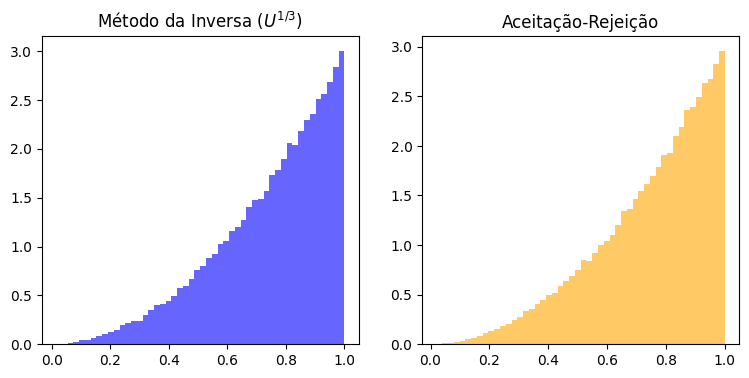

In [ ]:
#c) Compare com método da inversa.
import time
N = 100000

# Método da inversa
start_inv = time.time()
u_inv = np.random.uniform(0, 1, N)
amostras_inversa = u_inv**(1/3) 
tempo_inv = time.time() - start_inv

# metodo de aceitação-rejeição
# g(x) = 1 (Uniforme), c = 3 (máximo de f(x))
amostras_ar = []
tentativas = 0
start_ar = time.time()

while len(amostras_ar) < N:
    tentativas += 1
    Y = np.random.uniform(0, 1) #  g(x)
    U = np.random.uniform(0, 1) # Variável de decisão
    if U <= Y**2:               # Condição f(Y)/(c*g(Y)) = 3Y^2 / 3 = Y^2
        amostras_ar.append(Y)
tempo_ar = time.time() - start_ar
print(f"Inversa: {N} sorteios para {N} amostras (100% eficiente)")
print(f"Aceitação-rejeição: {tentativas} sorteios para {N} amostras (33% eficiente)")


# comparação e gráficos
plt.figure(figsize=(9, 4))
plt.subplot(1, 2, 1)
plt.hist(amostras_inversa, bins=50, density=True, color='blue', alpha=0.6)
plt.title('Método da Inversa ($U^{1/3}$)')
plt.subplot(1, 2, 2)
plt.hist(amostras_ar, bins=50, density=True, color='orange', alpha=0.6)
plt.title('Aceitação-Rejeição')
plt.show()

Eficiência Inversa: 100.00%
Eficiência Aceitação-Rejeição: 33.35%
Sorteios totais (A-R): 599718


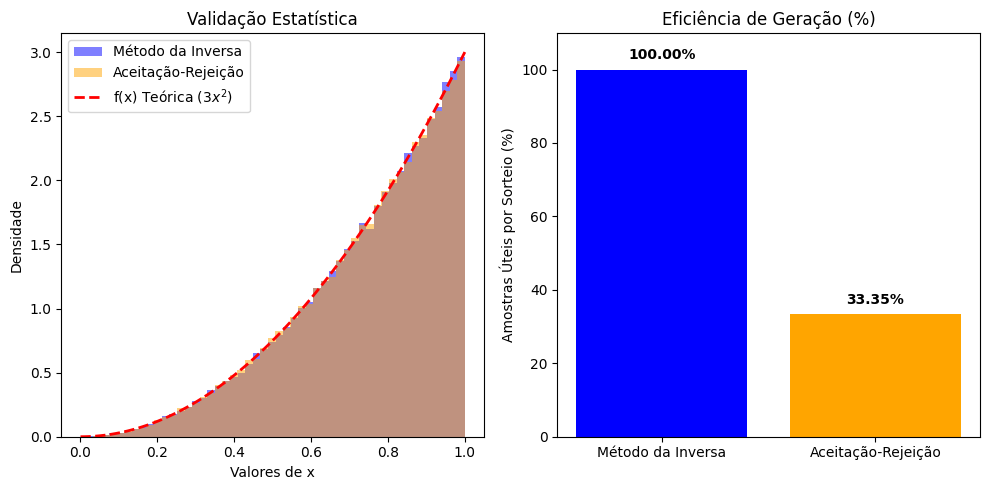

In [ ]:
#d) Discuta eficiência.
N = 100000

# simulação do método da inversa
# Cada sorteio vai gerar uma amostra. Eficiência sempre 100%
sorteios_inv = N
amostras_inv = np.random.uniform(0, 1, N)**(1/3)

#simulacao do método de aceitação-rejeição
amostras_AR = []
tentativas_AR = 0 # Contador
while len(amostras_AR) < N:
    tentativas_AR += 1
    Y = np.random.uniform(0, 1) # Variável da g(x)
    U = np.random.uniform(0, 1) # Variável de decisão
    if U <= Y**2:               # Condição f(Y)/(c*g(Y))
        amostras_AR.append(Y)

#calculo da eficiência
eficiencia_inv = (N / sorteios_inv) * 100
eficiencia_ar = (N / tentativas_AR) * 100

print(f"Eficiência Inversa: {eficiencia_inv:.2f}%")
print(f"Eficiência Aceitação-Rejeição: {eficiencia_ar:.2f}%")
print(f"Sorteios totais (A-R): {tentativas_AR * 2}")


# GRÁFICOS
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Gráfico 1: Validação das Distribuições
x = np.linspace(0, 1, 100)
ax1.hist(amostras_inv, bins=50, density=True, alpha=0.5, label='Método da Inversa', color='blue')
ax1.hist(amostras_AR, bins=50, density=True, alpha=0.5, label='Aceitação-Rejeição', color='orange')
ax1.plot(x, 3*x**2, 'r--', lw=2, label='f(x) Teórica ($3x^2$)')
ax1.set_title('Validação Estatística')
ax1.set_xlabel('Valores de x')
ax1.set_ylabel('Densidade')
ax1.legend()

# Gráfico 2: Comparação de Eficiência (%)
metodos = ['Método da Inversa', 'Aceitação-Rejeição']
valores = [eficiencia_inv, eficiencia_ar]
bars = ax2.bar(metodos, valores, color=['blue', 'orange'])
ax2.set_ylim(0, 110)
ax2.set_title('Eficiência de Geração (%)')
ax2.set_ylabel('Amostras Úteis por Sorteio (%)')

#Rótulos de dados nas barras
for bar in bars:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 2, f'{yval:.2f}%', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()